# Credit Risk EDA — Home Credit Default Risk Dataset
**Author:** Nico Avila
**Date:** March 2026  
**Input:** application_train.csv (307,511 rows · 122 raw features)
**Output:** cleaned_data.csv (Baseline for Feature Engineering)


## Objective
Explore the Home Credit dataset to identify key predictors of loan default,
assess data quality, and generate insights to inform feature engineering
and credit scorecard modelling.

## Data loading
Loading the Home Credit dataset and inspecting basic structure...

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\U\Desktop\CreditRisk\application_train.csv')
print(df.shape)
print(df.head(2))

(307511, 122)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0                0                0                0   
1  ...                 0                0                0                0   

  AMT_REQ_CREDIT_BUREAU_HOUR AMT_REQ_CREDIT_BUREAU_DAY  \
0                        0.0                       0.0   
1                        0.0                       0.0   

   AMT_REQ_CREDIT_BUREAU_WEEK  AMT_REQ_CREDIT_BUREAU_MON  \
0                         0.0                        0.0   
1         

In [2]:
# Dataset overview
print("=== SHAPE ===")
print(df.shape)

print("\n=== TARGET DISTRIBUTION ===")
print(df['TARGET'].value_counts())
print(f"Default rate: {df['TARGET'].mean():.1%}")

print("\n=== MISSING VALUES (top 15) ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.head(15))

print("\n=== KEY COLUMN STATS ===")
print(df[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','DAYS_BIRTH']].describe())

=== SHAPE ===
(307511, 122)

=== TARGET DISTRIBUTION ===
TARGET
0    282686
1     24825
Name: count, dtype: int64
Default rate: 8.1%

=== MISSING VALUES (top 15) ===
COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
dtype: int64

=== KEY COLUMN STATS ===
       AMT_INCOME_TOTAL    AMT_CREDIT    AMT_ANNUITY     DAYS_BIRTH
count      3.075110e+05  3.075110e+05  307499.000000  307511.000000
mean       1.687979e+05  5.990260e+05   27108.573909  -16036.995067
std        2.371231e+05  4.024908e+05   14493.737315    4363.98863

## Exploratory analysis
Examining default rates, demographics, and financial indicators
across 9 key dimensions...

In [3]:
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365
df['EMPLOYMENT_YEARS'] = df['DAYS_EMPLOYED'].clip(upper=0) / -365
df['CREDIT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

print("Data loaded and columns recreated successfully")
print(f"Shape: {df.shape}")

Data loaded and columns recreated successfully
Shape: (307511, 125)


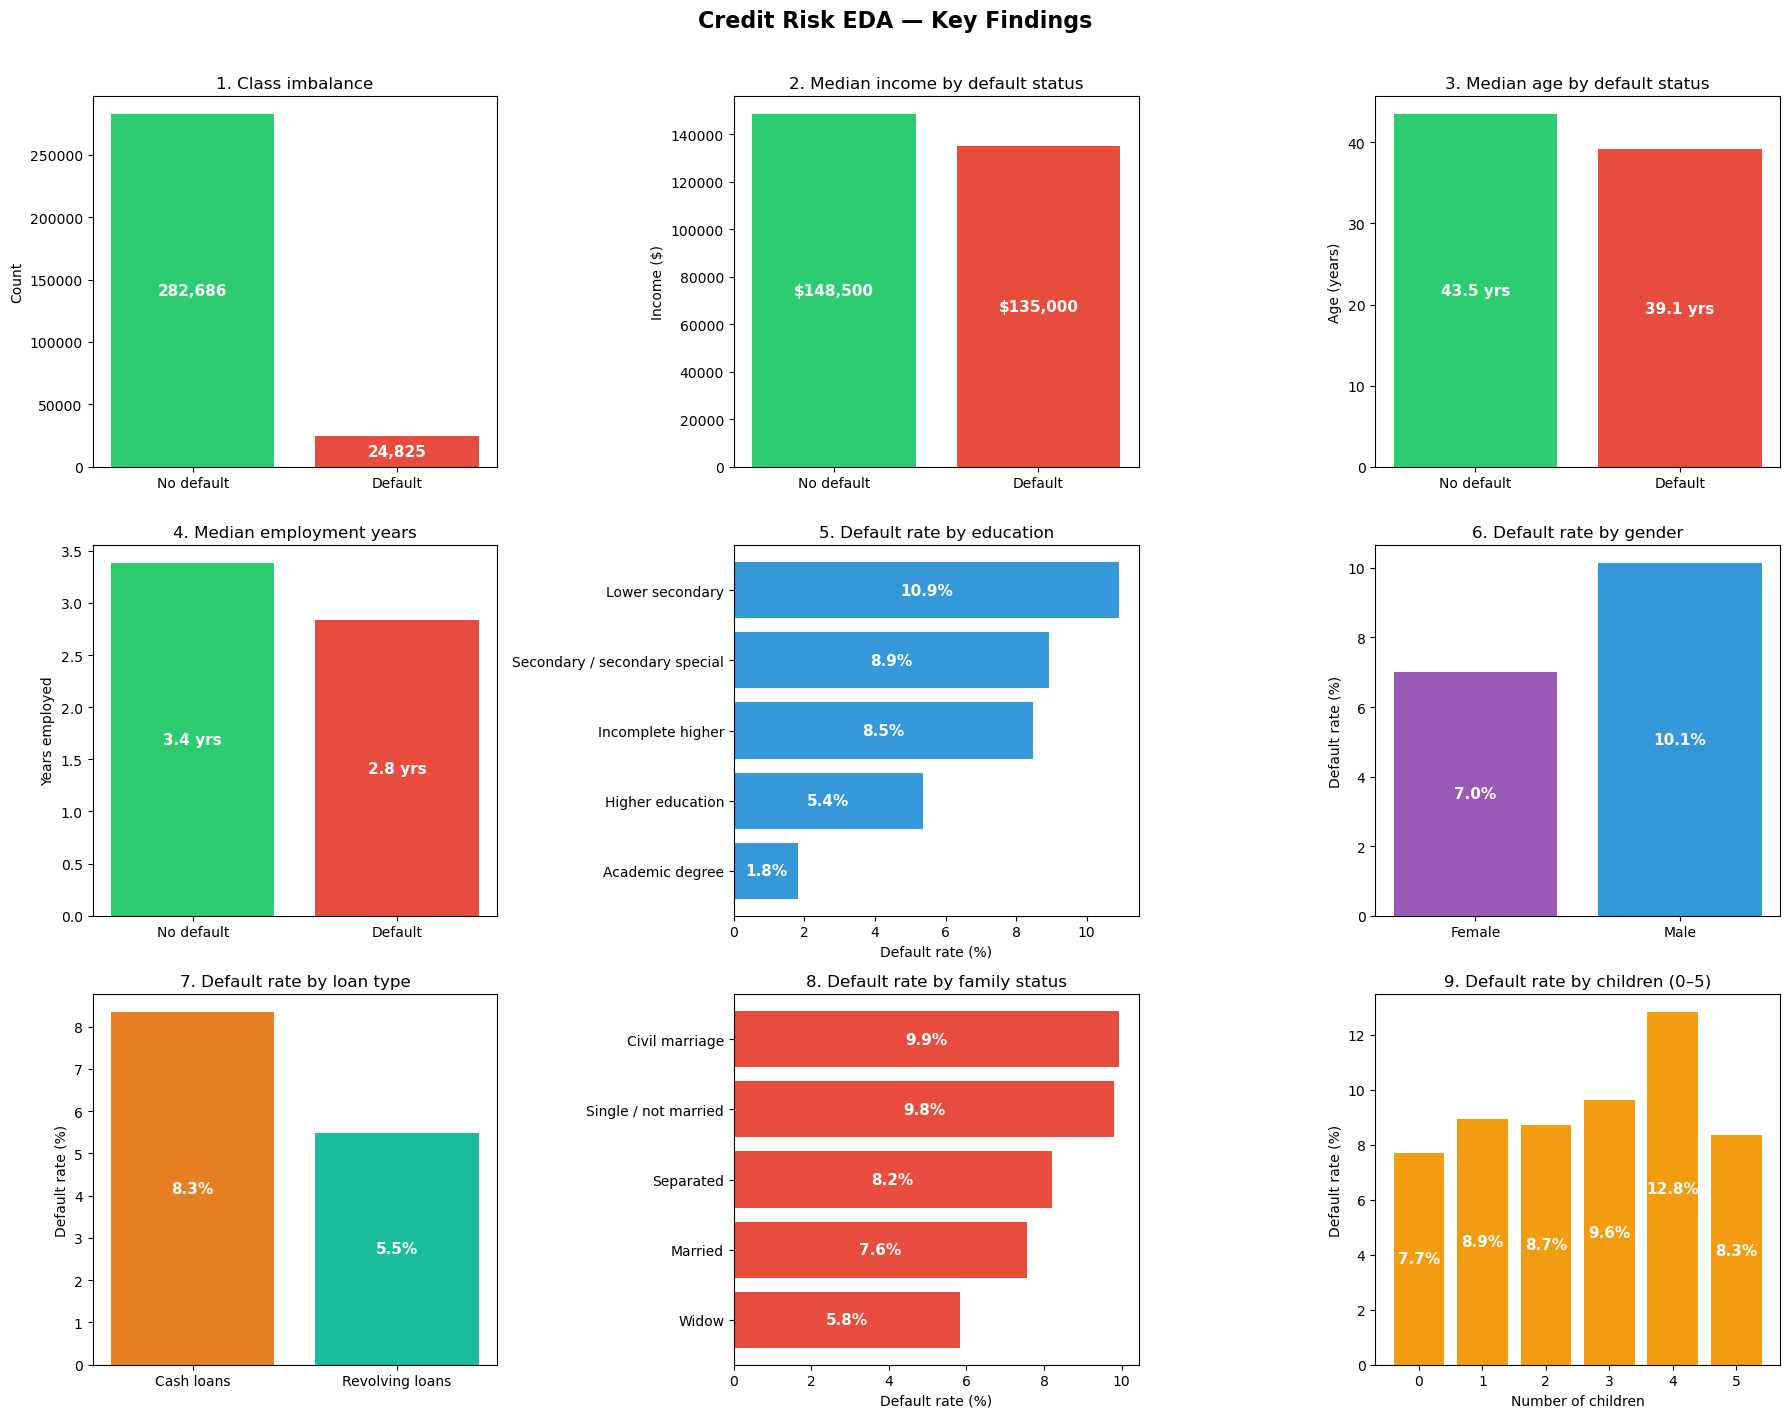

Chart saved to CreditRisk folder


In [4]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Credit Risk EDA — Key Findings', fontsize=16, fontweight='bold', y=1.01)

colors = ['#2ecc71', '#e74c3c']

# 1. Class imbalance
target_counts = df['TARGET'].value_counts()
bars = axes[0,0].bar(['No default', 'Default'], target_counts.values, color=colors)
axes[0,0].set_title('1. Class imbalance')
axes[0,0].set_ylabel('Count')
for bar, v in zip(bars, target_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                   f'{v:,}', ha='center', va='center', fontweight='bold', color='white', fontsize=11)

# 2. Median income by default
income = df.groupby('TARGET')['AMT_INCOME_TOTAL'].median()
bars = axes[0,1].bar(['No default', 'Default'], income.values, color=colors)
axes[0,1].set_title('2. Median income by default status')
axes[0,1].set_ylabel('Income ($)')
for bar, v in zip(bars, income.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                   f'${v:,.0f}', ha='center', va='center', fontweight='bold', color='white', fontsize=11)

# 3. Median age by default
age = df.groupby('TARGET')['AGE_YEARS'].median()
bars = axes[0,2].bar(['No default', 'Default'], age.values, color=colors)
axes[0,2].set_title('3. Median age by default status')
axes[0,2].set_ylabel('Age (years)')
for bar, v in zip(bars, age.values):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                   f'{v:.1f} yrs', ha='center', va='center', fontweight='bold', color='white', fontsize=11)

# 4. Employment years by default
emp = df.groupby('TARGET')['EMPLOYMENT_YEARS'].median()
bars = axes[1,0].bar(['No default', 'Default'], emp.values, color=colors)
axes[1,0].set_title('4. Median employment years')
axes[1,0].set_ylabel('Years employed')
for bar, v in zip(bars, emp.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                   f'{v:.1f} yrs', ha='center', va='center', fontweight='bold', color='white', fontsize=11)

# 5. Education level default rate
edu = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().mul(100).sort_values()
bars = axes[1,1].barh(edu.index, edu.values, color='#3498db')
axes[1,1].set_title('5. Default rate by education')
axes[1,1].set_xlabel('Default rate (%)')
for bar, v in zip(bars, edu.values):
    axes[1,1].text(bar.get_width()*0.5, bar.get_y() + bar.get_height()/2,
                   f'{v:.1f}%', ha='center', va='center', fontweight='bold', color='white', fontsize=11)

# 6. Gender default rate
gender = df[df['CODE_GENDER'] != 'XNA'].groupby('CODE_GENDER')['TARGET'].mean().mul(100)
bars = axes[1,2].bar(['Female', 'Male'], gender.values, color=['#9b59b6', '#3498db'])
axes[1,2].set_title('6. Default rate by gender')
axes[1,2].set_ylabel('Default rate (%)')
for bar, v in zip(bars, gender.values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                   f'{v:.1f}%', ha='center', va='center', fontweight='bold', color='white', fontsize=11)

# 7. Loan type default rate
loan = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean().mul(100)
bars = axes[2,0].bar(loan.index, loan.values, color=['#e67e22', '#1abc9c'])
axes[2,0].set_title('7. Default rate by loan type')
axes[2,0].set_ylabel('Default rate (%)')
for bar, v in zip(bars, loan.values):
    axes[2,0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                   f'{v:.1f}%', ha='center', va='center', fontweight='bold', color='white', fontsize=11)

# 8. Family status default rate
family = df[df['NAME_FAMILY_STATUS'] != 'Unknown'].groupby(
    'NAME_FAMILY_STATUS')['TARGET'].mean().mul(100).sort_values()
bars = axes[2,1].barh(family.index, family.values, color='#e74c3c')
axes[2,1].set_title('8. Default rate by family status')
axes[2,1].set_xlabel('Default rate (%)')
for bar, v in zip(bars, family.values):
    axes[2,1].text(bar.get_width()*0.5, bar.get_y() + bar.get_height()/2,
                   f'{v:.1f}%', ha='center', va='center', fontweight='bold', color='white', fontsize=11)

# 9. Children count default rate (capped at 5)
children = df[df['CNT_CHILDREN'] <= 5].groupby(
    'CNT_CHILDREN')['TARGET'].mean().mul(100)
bars = axes[2,2].bar(children.index.astype(str), children.values, color='#f39c12')
axes[2,2].set_title('9. Default rate by children (0–5)')
axes[2,2].set_xlabel('Number of children')
axes[2,2].set_ylabel('Default rate (%)')
for bar, v in zip(bars, children.values):
    axes[2,2].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                   f'{v:.1f}%', ha='center', va='center', fontweight='bold', color='white', fontsize=11)

plt.tight_layout()
plt.savefig(r'C:\Users\U\Desktop\CreditRisk\eda_findings.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to CreditRisk folder")

## Key findings
--- 

**Finding 1 — Income & Age: Primary risk signals**

The younger and lower income segment is where the risk is. 
Defaulters earn about 10% less (median $135k) and are roughly 4 years younger on average (39.1 vs 43.5 years). 
Definitely keeping these as top-tier predictors.

---

**Finding 2 — Employment stability matters**

Tenure matters. Non-defaulters have a median of 3.4 years on the job vs 2.8 years for defaulters. 
It’s a good proxy for income stability, so I’m including this as a feature.

---

**Finding 3 — Education level shows the strongest gradient**

This is the cleanest categorical signal I've found. 
Default rates jump from 1.8% (academic degree) to 10.9% (lower secondary)—that's a 6x difference. 
Huge for the model.

---

**Finding 4 — Gender is a meaningful but sensitive signal**

Males default at 10.1% vs 7.0% for females (a 44% higher relative rate). 
It’s a strong signal, but I’ve already flagged this for the model card to make sure we’re looking at fairness.

---

**Finding 5 — Loan type carries moderate signal**

Cash loans (8.3%) default more than revolving loans (5.5%). 
Revolving applicants likely represent lower-risk repeat customers.

---

**Finding 6 — Marital status**

Civil marriage (9.9%) and single applicants (9.8%) default at higher rates
than married (7.6%) and widowed (5.8%) applicants. This reflects financial stability.
Marital status will be encoded as a categorical feature in the model.

---

**Finding 7 — Children count requires careful treatment**

For 0–3 children a modest positive relationship exists with default risk.
Extreme values (9–11 children) show 100% default rates but represent
fewer than 5 applicants and are statistically unreliable. Outliers. 

---

**Finding 8 — Credit-to-income ratio works in combination**

Median ratio is nearly identical across groups (3.27 vs 3.25) standalone.
The predictive value emerges when combined with income level and age.

---

> **Modelling note:** Class imbalance (8.1% default rate) requires
> `class_weight='balanced'` in the logistic regression model.


In [5]:
print(f"Average loan amount: ${df['AMT_CREDIT'].mean():,.0f}")
print(f"Median loan amount: ${df['AMT_CREDIT'].median():,.0f}")

Average loan amount: $599,026
Median loan amount: $513,531


In [6]:
# Check average loan amount and estimate recovery scenario
avg_loan = df['AMT_CREDIT'].mean()
default_rate = df['TARGET'].mean()
total_portfolio = avg_loan * len(df)

# Assuming 10% margin on performing loans
margin = 0.10

# Profit per good loan
profit_per_good_loan = avg_loan * margin

# Loss per defaulted loan (assuming zero recovery)
loss_per_default_zero_recovery = avg_loan * 1.0

# Loss per defaulted loan (assuming 40% recovery)
loss_per_default_40_recovery = avg_loan * 0.60

print(f"Average loan amount: {avg_loan:,.0f} rubles (${avg_loan * 0.011:,.0f} USD)")
print(f"Profit per good loan (10% margin): {profit_per_good_loan:,.0f} rubles")
print(f"Loss per default (0% recovery): {loss_per_default_zero_recovery:,.0f} rubles")
print(f"Loss per default (40% recovery): {loss_per_default_40_recovery:,.0f} rubles")
print(f"\n--- Breakeven loans needed ---")
print(f"Zero recovery: {loss_per_default_zero_recovery / profit_per_good_loan:.1f} good loans per default")
print(f"40% recovery:  {loss_per_default_40_recovery / profit_per_good_loan:.1f} good loans per default")
print(f"\n--- Portfolio impact ---")
print(f"Total defaults in dataset: {df['TARGET'].sum():,}")
print(f"Total portfolio value: {total_portfolio:,.0f} rubles (${total_portfolio * 0.011:,.0f} USD)")
print(f"Total default losses (0% recovery): ${df['TARGET'].sum() * avg_loan * 0.011:,.0f} USD")
print(f"Total default losses (40% recovery): ${df['TARGET'].sum() * avg_loan * 0.60 * 0.011:,.0f} USD")

Average loan amount: 599,026 rubles ($6,589 USD)
Profit per good loan (10% margin): 59,903 rubles
Loss per default (0% recovery): 599,026 rubles
Loss per default (40% recovery): 359,416 rubles

--- Breakeven loans needed ---
Zero recovery: 10.0 good loans per default
40% recovery:  6.0 good loans per default

--- Portfolio impact ---
Total defaults in dataset: 24,825
Total portfolio value: 184,207,084,196 rubles ($2,026,277,926 USD)
Total default losses (0% recovery): $163,579,025 USD
Total default losses (40% recovery): $98,147,415 USD


In [7]:
# --- Credit Risk EDA Findings Summary ---

print("1. Class Imbalance (Target Distribution)")
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100
print(f"   - No Default: {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"   - Default:    {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print("-" * 30)

print("2. Median Income by Default Status")
income = df.groupby('TARGET')['AMT_INCOME_TOTAL'].median()
print(f"   - No Default: ${income[0]:,.0f}")
print(f"   - Default:    ${income[1]:,.0f}")
print("-" * 30)

print("3. Median Age by Default Status")
age = df.groupby('TARGET')['AGE_YEARS'].median()
print(f"   - No Default: {age[0]:.1f} years")
print(f"   - Default:    {age[1]:.1f} years")
print("-" * 30)

print("4. Median Employment Years")
emp = df.groupby('TARGET')['EMPLOYMENT_YEARS'].median()
print(f"   - No Default: {emp[0]:.1f} years")
print(f"   - Default:    {emp[1]:.1f} years")
print("-" * 30)

print("5. Default Rate by Education (%)")
edu = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().mul(100).sort_values(ascending=False)
for level, rate in edu.items():
    print(f"   - {level:25}: {rate:.2f}%")
print("-" * 30)

print("6. Default Rate by Gender (%)")
gender = df[df['CODE_GENDER'] != 'XNA'].groupby('CODE_GENDER')['TARGET'].mean().mul(100)
print(f"   - Female: {gender.get('F', 0):.2f}%")
print(f"   - Male:   {gender.get('M', 0):.2f}%")
print("-" * 30)

print("7. Default Rate by Loan Type (%)")
loan = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean().mul(100)
for l_type, rate in loan.items():
    print(f"   - {l_type:15}: {rate:.2f}%")
print("-" * 30)

print("8. Default Rate by Family Status (%)")
family = df[df['NAME_FAMILY_STATUS'] != 'Unknown'].groupby('NAME_FAMILY_STATUS')['TARGET'].mean().mul(100).sort_values(ascending=False)
for status, rate in family.items():
    print(f"   - {status:25}: {rate:.2f}%")
print("-" * 30)

print("9. Default Rate by Children Count (0-5)")
children = df[df['CNT_CHILDREN'] <= 5].groupby('CNT_CHILDREN')['TARGET'].mean().mul(100)
for count, rate in children.items():
    print(f"   - {int(count)} Children: {rate:.2f}%")

1. Class Imbalance (Target Distribution)
   - No Default: 282,686 (91.9%)
   - Default:    24,825 (8.1%)
------------------------------
2. Median Income by Default Status
   - No Default: $148,500
   - Default:    $135,000
------------------------------
3. Median Age by Default Status
   - No Default: 43.5 years
   - Default:    39.1 years
------------------------------
4. Median Employment Years
   - No Default: 3.4 years
   - Default:    2.8 years
------------------------------
5. Default Rate by Education (%)
   - Lower secondary          : 10.93%
   - Secondary / secondary special: 8.94%
   - Incomplete higher        : 8.48%
   - Higher education         : 5.36%
   - Academic degree          : 1.83%
------------------------------
6. Default Rate by Gender (%)
   - Female: 7.00%
   - Male:   10.14%
------------------------------
7. Default Rate by Loan Type (%)
   - Cash loans     : 8.35%
   - Revolving loans: 5.48%
------------------------------
8. Default Rate by Family Status (%)

In [8]:
df.to_csv(r'C:\Users\U\Desktop\CreditRisk\cleaned_data.csv', index=False)
print("Cleaned data saved successfully for Phase 3!")

Cleaned data saved successfully for Phase 3!
